# Rydberg sensitivity of the hydrogen SE populations

How much does swapping the Rydberg constant from the infinite-mass value to the
measured H ionization move the statistical-equilibrium (SE) level populations?

$$R_\infty = 109737.316\ \mathrm{cm^{-1}}\ \text{(Bohr, infinite nuclear mass)}
  \quad\longrightarrow\quad
  R_H = 109678.758\ \mathrm{cm^{-1}}\ \text{(measured, NIST / RH)}.$$

The fractional drop is tiny, $\Delta R / R_\infty \approx 5.34\times10^{-4}$
($\Delta\chi \approx 7.4\times10^{-3}$ eV in the ionization energy), but it
propagates non-uniformly through the SE solve. This notebook maps the effect
over $T_e \in \{7000, 10000, 50000\}$ K and
$N_e \in \{10^8, \dots, 10^{13}\}\ \mathrm{cm^{-3}}$.

This notebook is **generated** from `build_notebook.py` in this folder.
Re-run the script after any change to the SE / Atomic / Constants APIs.


## How the Rydberg enters the SE solve

`SELib.cal_SE_with_Ne_Te_` returns the normalized population vector `n_SE`
(sums to 1; `n_SE[0]` = neutral ground $n_1$, `n_SE[-1]` = ionization fraction
$n_p/N_\mathrm{tot}$). The analysis tracks four indices throughout — the first
three bound levels $n_1, n_2, n_3$ and the ionization fraction
$n_p/N_\mathrm{tot}$. The Rydberg reaches them through **two channels**:

| channel | where | mechanism |
|---|---|---|
| **level energies** | `atom.Level["erg"]` in the Saha/Boltzmann factors | $\exp(-E/kT_e)$ — thermodynamic balance |
| **rate coefficients** | `Hydrogen.CE_rate_coe_`, `CI_rate_coe_`, PI cross-sections | $E_{ij} = E_\mathrm{Ry}\,(1/n_i^2 - 1/n_j^2)$ — kinetic rates |
| **radiative sampling** | line/continuum $\lambda$ where the incident field is read | shifted $E_{ij}$ moves $\lambda$ across a non-Planckian solar spectrum |

The *theoretical* hydrogen atom rebuilds the first two from the one constant
`Constants.E_Rydberg_H_`, so a single monkeypatch toggles the whole solve
self-consistently (numba JIT is off, every lookup is qualified `CST.E_Rydberg_H_`).

**No clean analytic limit.** The solve is driven by the *default solar radiation
field* (`se_params=None` ⇒ `radiation.solar`), **not** a Planck function at $T_e$.
Because that field is not thermal, there is no single closed form for the shift —
it is mapped numerically below. Only the **ground state at high $N_e$**, where
collisions fully enforce LTE, recovers the Saha scaling
$\Delta n_1/n_1 \approx -\Delta\chi/kT_e \approx -1\%$ at $7000$ K. The excited
levels and the ionization fraction are set by the radiative rates and move by
order-unity fractions of their (small) populations — consistent with the Rydberg
shift dragging line wavelengths across a steeply varying solar UV field, which
*amplifies* rather than damps the sensitivity.


## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import spectra.Constants as CST
from spectra.Atomic import Hydrogen
from spectra.Function.SEquil import SELib
from spectra.Struct import Atmosphere, Atom, Radiation

# the patch only propagates if the rate modules share this Constants object
assert Hydrogen.CST is CST, "Rydberg monkeypatch would not reach the rate functions"

NLEVEL = 11          # n=1..10 bound + continuum (matches data/atom/H/H.Level)
VT = 5.0e5           # microturbulent velocity [cm/s]; affects only line widths

R_INF_CM = 109737.316   # R_inf, infinite nuclear mass (Bohr)         [cm^-1]
R_H_CM = 109678.758     # measured H ionization (NIST / RH)           [cm^-1]

TE_LIST = [7000.0, 10000.0, 50000.0]                       # [K]
NE_LIST = [1e8, 1e9, 1e10, 1e11, 1e12, 1e13]               # [cm^-3]

_R_MEASURED_ERG = CST.E_Rydberg_H_   # restore at the end


# Patch the module-level Rydberg energy [erg]. JIT is off, so every qualified
# CST.E_Rydberg_H_ lookup in the rate functions and in the theoretical-atom
# builder picks this up at call time.
def set_rydberg(R_cm):
    CST.E_Rydberg_H_ = R_cm * CST.c_ * CST.h_


# Theoretical H atom + SE solve at one (Rydberg, Te, Ne). Both the level energies
# and the rate coefficients track R_cm. Returns the normalized population vector.
def solve_SE(R_cm, Te, Ne):
    set_rydberg(R_cm)
    atom = Atom.init_theoretical_hydrogen_atom_(nLevel=NLEVEL)
    atmos = Atmosphere.Atmosphere0D(Nh=0, Ne=Ne, Te=Te, Vd_obs=0.0, Vd_sun=0.0, Vt=VT)
    radiation = Radiation.init_Radiation_()
    se, _ = SELib.cal_SE_with_Ne_Te_(atom, atmos, radiation, None)
    return se.n_SE


## Compute the grid

$2 \times 3 \times 6 = 36$ SE solves (sub-second total).


In [2]:
shape = (len(TE_LIST), len(NE_LIST))
n_inf = np.empty(shape, dtype=object)   # R_inf populations per cell
n_meas = np.empty(shape, dtype=object)  # measured-R populations per cell

for i, Te in enumerate(TE_LIST):
    for j, Ne in enumerate(NE_LIST):
        n_inf[i, j] = solve_SE(R_INF_CM, Te, Ne)
        n_meas[i, j] = solve_SE(R_H_CM, Te, Ne)

set_rydberg(R_H_CM)  # leave the module at the production (measured) value
assert abs(CST.E_Rydberg_H_ - _R_MEASURED_ERG) / _R_MEASURED_ERG < 1e-12


# (measured - R_inf) / R_inf of one level's population, over the grid.
def rel_change(level_index):
    out = np.zeros(shape)
    for i in range(shape[0]):
        for j in range(shape[1]):
            a, b = n_inf[i, j][level_index], n_meas[i, j][level_index]
            out[i, j] = (b - a) / a if a != 0.0 else 0.0
    return out


d_n1 = rel_change(0)       # neutral ground       n_1
d_n2 = rel_change(1)       # first excited        n_2
d_n3 = rel_change(2)       # second excited       n_3
d_ion = rel_change(-1)     # ionization fraction  n_p / N_tot
print("ionization fraction (measured R_H), grid [Te x Ne]:")
print(np.array([[n_meas[i, j][-1] for j in range(shape[1])] for i in range(shape[0])]))


ionization fraction (measured R_H), grid [Te x Ne]:
[[0.99900254 0.99011063 0.90890777 0.49401249 0.08672311 0.01082072]
 [0.99924248 0.99247983 0.92988762 0.58033114 0.14510442 0.03378797]
 [0.99989863 0.99980874 0.99979035 0.99979034 0.99979962 0.99982227]]


## Summary table

Relative population change $(n_{R_H} - n_{R_\infty})/n_{R_\infty}$ per cell.


In [3]:
def fmt_row(name, arr, i):
    return f"  {name:<10}" + "".join(f"{arr[i, j]:+11.2e}" for j in range(shape[1]))


hdr = "Ne [cm^-3]:" + "".join(f"{ne:>11.0e}" for ne in NE_LIST)
for i, Te in enumerate(TE_LIST):
    print(f"\nTe = {Te:.0f} K")
    print(hdr)
    print(fmt_row("d n=1", d_n1, i))
    print(fmt_row("d n=2", d_n2, i))
    print(fmt_row("d n=3", d_n3, i))
    print(fmt_row("d ion", d_ion, i))



Te = 7000 K
Ne [cm^-3]:      1e+08      1e+09      1e+10      1e+11      1e+12      1e+13
  d n=1       -6.88e-01  -6.82e-01  -6.27e-01  -3.47e-01  -6.33e-02  -8.29e-03
  d n=2       +2.18e+00  +2.24e+00  +2.80e+00  +5.66e+00  +8.55e+00  +9.11e+00
  d n=3       +3.29e-01  +3.54e-01  +5.86e-01  +1.78e+00  +3.03e+00  +3.66e+00
  d ion       +2.20e-03  +2.19e-02  +2.03e-01  +1.19e+00  +2.46e+00  +3.24e+00

Te = 10000 K
Ne [cm^-3]:      1e+08      1e+09      1e+10      1e+11      1e+12      1e+13
  d n=1       -6.94e-01  -6.89e-01  -6.48e-01  -4.12e-01  -1.07e-01  -2.55e-02
  d n=2       +2.18e+00  +2.23e+00  +2.66e+00  +5.11e+00  +8.23e+00  +8.55e+00
  d n=3       +3.52e-01  +3.72e-01  +5.55e-01  +1.59e+00  +2.96e+00  +3.41e+00
  d ion       +1.72e-03  +1.71e-02  +1.61e-01  +1.03e+00  +2.41e+00  +2.96e+00

Te = 50000 K
Ne [cm^-3]:      1e+08      1e+09      1e+10      1e+11      1e+12      1e+13
  d n=1       -3.81e-01  -7.36e-02  -9.84e-03  -2.49e-03  -7.83e-04  +1.23e-03
  d n=2       

## Heatmaps — $T_e \times N_e$

Diverging colour scale centred at zero; annotations are the relative change.


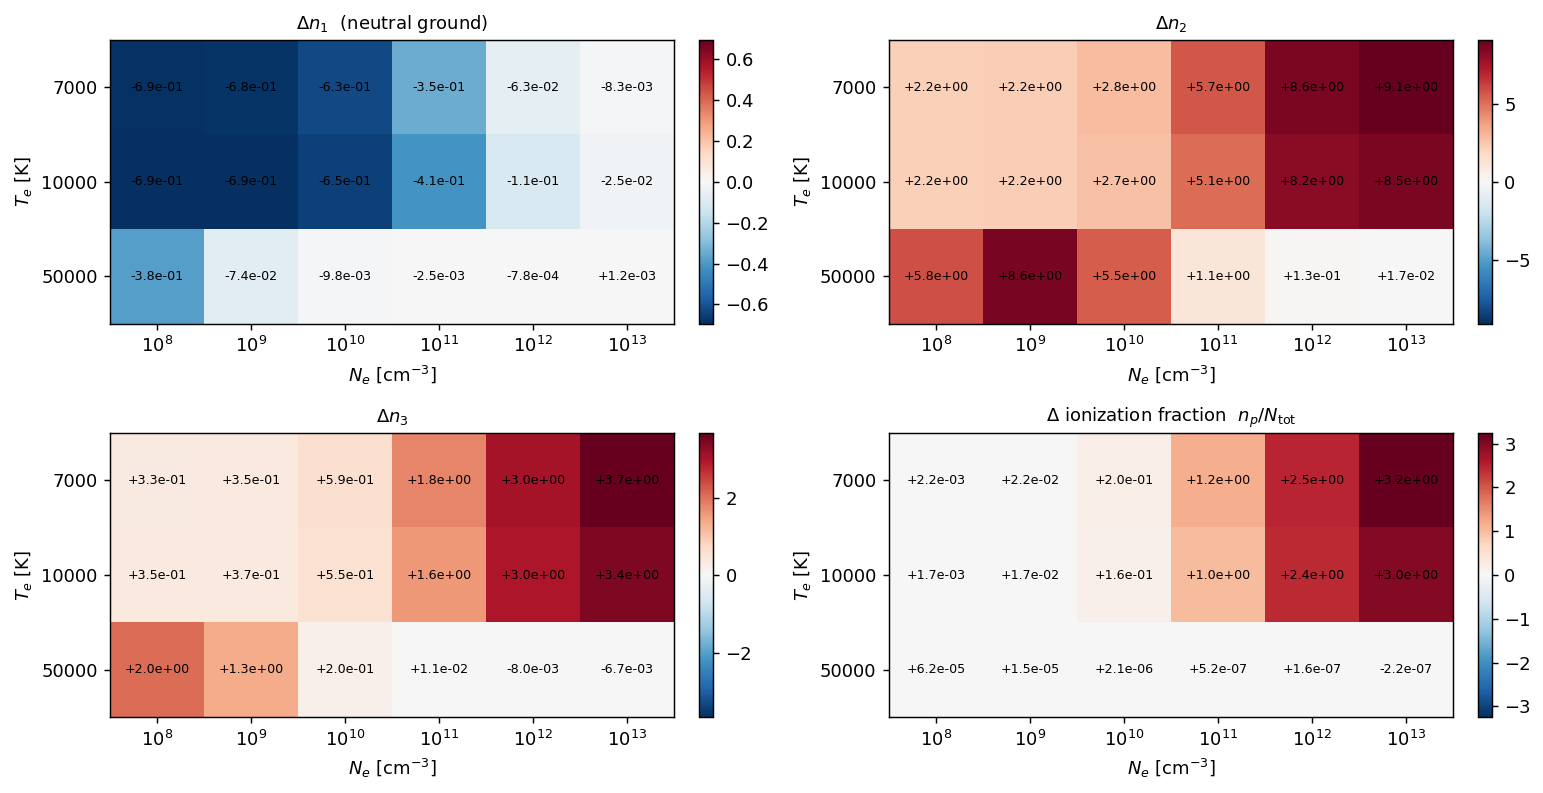

In [4]:
def heatmap(ax, data, title):
    vmax = np.abs(data).max()
    im = ax.imshow(data, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(NE_LIST)))
    ax.set_xticklabels([f"$10^{{{int(np.log10(ne))}}}$" for ne in NE_LIST])
    ax.set_yticks(range(len(TE_LIST)))
    ax.set_yticklabels([f"{int(te)}" for te in TE_LIST])
    ax.set_xlabel(r"$N_e$ [cm$^{-3}$]")
    ax.set_ylabel(r"$T_e$ [K]")
    ax.set_title(title, fontsize=10)
    for i in range(len(TE_LIST)):
        for j in range(len(NE_LIST)):
            ax.text(j, i, f"{data[i, j]:+.1e}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


fig, axes = plt.subplots(2, 2, figsize=(12, 6.2), dpi=130)
heatmap(axes[0, 0], d_n1, r"$\Delta n_1$  (neutral ground)")
heatmap(axes[0, 1], d_n2, r"$\Delta n_2$")
heatmap(axes[1, 0], d_n3, r"$\Delta n_3$")
heatmap(axes[1, 1], d_ion, r"$\Delta$ ionization fraction  $n_p/N_\mathrm{tot}$")
plt.tight_layout()
plt.show()


**Reading the maps.**

- **Ground state $n_1$** moves most at **low $N_e$** (radiation-dominated,
  reaching $\sim-70\%$) and relaxes toward the small Saha value ($\sim-1\%$) at
  high $N_e$, where collisions enforce LTE. It is weakest at high $T_e$.
- **Excited $n_2, n_3$** show large *positive* relative changes (order unity to
  several hundred percent) — large fractions of very small populations, driven by
  the radiative rates rather than the Saha binding-energy shift.
- **Ionization fraction** is insensitive wherever H is fully ionized (high
  $T_e$, or low $N_e$) and moves most at **low $T_e$ / high $N_e$**, where the
  ion is a deep-tail minority.


## Per-level change at one representative cell


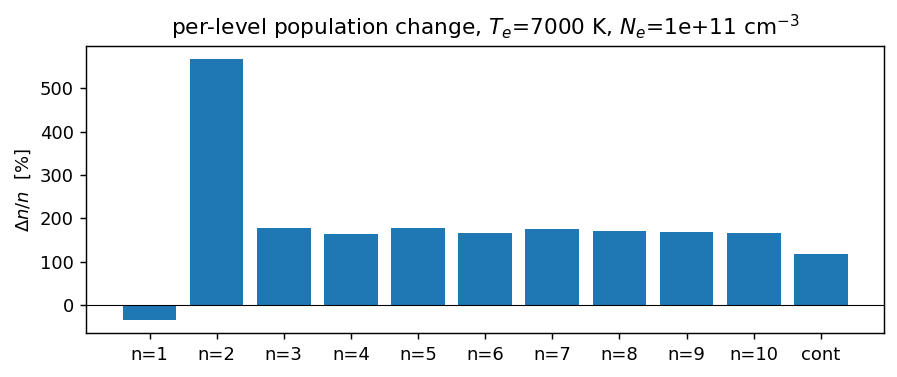

In [5]:
i_rep, j_rep = 0, 3   # Te=7000 K, Ne=1e11 cm^-3
a, b = n_inf[i_rep, j_rep], n_meas[i_rep, j_rep]
levels = np.arange(NLEVEL)
rel = np.where(a != 0.0, (b - a) / a, 0.0)

fig, ax = plt.subplots(1, 1, figsize=(7, 3), dpi=130)
ax.bar(levels, rel * 100.0, color="C0")
ax.axhline(0.0, color="k", lw=0.6)
ax.set_xticks(levels)
ax.set_xticklabels([f"n={n + 1}" for n in range(NLEVEL - 1)] + ["cont"])
ax.set_ylabel(r"$\Delta n / n$  [%]")
ax.set_title(
    rf"per-level population change, $T_e$={TE_LIST[i_rep]:.0f} K, "
    rf"$N_e$={NE_LIST[j_rep]:.0e} cm$^{{-3}}$"
)
plt.tight_layout()
plt.show()


## Takeaway

Under a realistic solar radiation field (`se_params=None`) the Rydberg swap
$R_\infty \to R_H$ ($\sim$0.05% in the constant) does **not** reduce to a clean
Saha shift. Only the collision-dominated ground state at high $N_e$ recovers the
analytic $-\Delta\chi/kT_e \approx -1\%$ estimate. Elsewhere the effect is
radiative-rate driven: excited-level populations and the neutral/ion balance move
by order-unity fractions of their (typically small) populations, largest where the
affected species is a Boltzmann-tail minority. These are large *relative* swings
on small absolute populations, amplified by how the shifted line wavelengths
sample the non-thermal solar field — a realistic-conditions sensitivity, distinct
from the idealized LTE limit.
